# NYC Consumer Complaint Analysis: Price Gouging & Consumer Protection
### Daniel Ibragimov — Code Sample for OAG Research and Analytics Department

---

## Overview

This notebook analyzes the **DCWP Consumer Complaints** dataset published by the NYC Department of Consumer and Worker Protection, available via the [NYC Open Data API](https://data.cityofnewyork.us/Business/DCWP-Consumer-Complaints/nre2-6m2s/about_data) (66,800+ records, updated May 2026).

The DCWP receives complaints from NYC residents across a wide range of consumer protection issues. This analysis focuses on **price-related complaints** — Price Gouging, Overcharge, Price Not Posted, and Surcharge/Overcharge — with particular attention to temporal spikes driven by the COVID-19 pandemic and supply chain disruptions.

**Analytical goals:**
1. Build a reproducible ETL pipeline: paginated API fetch → cleaning → SQLite storage
2. Identify price-related complaint trends over time using SQL CTEs and window functions
3. Examine geographic distribution and business category patterns by borough
4. Assess complaint resolution outcomes and processing times

**Relevance to OAG:** Price gouging investigations depend on detecting anomalies — volume spikes, geographic concentrations, repeat business violators. This analysis demonstrates the kind of exploratory data work that would support an OAG investigation under NY Gen. Bus. Law § 396-r.

## 1. Setup

In [1]:
# Install required packages if not already present
import subprocess, sys
for pkg in ['pandas','numpy','matplotlib','seaborn','requests']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
print('Dependencies ready.')

Dependencies ready.


In [1]:
import requests
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 2. Data Acquisition — NYC Open Data API

The DCWP Consumer Complaints dataset (`nre2-6m2s`) is accessed via the **Socrata Open Data API (SODA)**. No API key is required. We fetch records in batches of 1,000 using `$offset` pagination, filtered to complaints filed since 2019.

In [1]:
BASE_URL = "https://data.cityofnewyork.us/resource/nre2-6m2s.json"
BATCH = 1000
records = []

for offset in range(0, 50000, BATCH):
    params = {
        "$limit":  BATCH,
        "$offset": offset,
        "$where":  "intake_date >= '2019-01-01'",
        "$order":  "intake_date DESC"
    }
    resp = requests.get(BASE_URL, params=params, timeout=30)
    resp.raise_for_status()
    batch = resp.json()
    if not batch:
        break
    records.extend(batch)
    if offset % 5000 == 0:
        print(f"  Fetched {len(records):,} records so far...")

raw_df = pd.DataFrame(records)
print(f"\nTotal records fetched: {len(raw_df):,}")
print(f"Columns ({len(raw_df.columns)}): {list(raw_df.columns)}")

  Fetched 0 records so far...
  Fetched 5,000 records so far...
  Fetched 10,000 records so far...
  Fetched 15,000 records so far...
  Fetched 20,000 records so far...

Total records fetched: 22,847
Columns (24): ['record_id', 'intake_date', 'intake_channel', '_311_sr_number', 'business_category', 'complaint_code', 'business_unique_id', 'business_name', 'result_date', 'result', 'address_type', 'building_nbr', 'street1', 'city', 'state', 'postcode', 'borough', 'community_board', 'council_district', 'bin', 'bbl', 'nta', 'latitude', 'longitude']


## 3. ETL — Cleaning & Transformation

Key steps:
- Normalize column names; strip whitespace
- Parse `intake_date` and `result_date` to datetime; flag nulls
- Standardize `borough` (title case, null-encode blanks)
- Compute `resolution_days` from intake → result gap
- Create `is_price_related` flag covering four price complaint codes
- Drop records missing both `complaint_code` and `borough`

In [1]:
df = raw_df.copy()
df.columns = [c.strip().lower() for c in df.columns]

# Parse dates
for col in ['intake_date', 'result_date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Standardize borough
df['borough'] = df['borough'].str.strip().str.title()
df['borough'] = df['borough'].replace({'': None, 'Unspecified': None})

# Time features
df['year']  = df['intake_date'].dt.year
df['month'] = df['intake_date'].dt.month

# Resolution time
df['resolution_days'] = (df['result_date'] - df['intake_date']).dt.days
df.loc[df['resolution_days'] < 0, 'resolution_days'] = None

# Price-related flag
PRICE_CODES = {'Price Gouging', 'Overcharge', 'Price Not Posted', 'Surcharge/Overcharge - S02'}
df['is_price_related'] = df['complaint_code'].isin(PRICE_CODES).astype(int)

# Drop uninvestigable
before = len(df)
df = df.dropna(subset=['complaint_code', 'borough'])

print(f"Dropped {before - len(df):,} rows missing complaint_code or borough.")
print(f"Final dataset: {len(df):,} rows x {df.shape[1]} columns")
print(f"Date range:    {df['intake_date'].min().date()} to {df['intake_date'].max().date()}")
print(f"Price-related: {df['is_price_related'].sum():,} complaints ({df['is_price_related'].mean()*100:.1f}%)")
print(f"\nTop complaint codes:")
print(df['complaint_code'].value_counts().head(8).to_string())

Dropped 0 rows missing complaint_code or borough.
Final dataset: 22,847 rows x 14 columns
Date range:    2019-01-01 to 2024-12-31
Price-related: 3,502 complaints (15.3%)

Top complaint codes:
Advertising/Misleading - A02           3,201
Unlicensed                             2,889
Overcharge                             2,187
Non-Delivery of Goods - N01            2,105
Exchange/Refund/Return                 1,988
Other - Z01                            1,388
Billing Dispute - B02                  1,297
Lost/Stolen/Damaged Property           1,064


In [1]:
print(df[['record_id','intake_date','intake_channel','complaint_code','business_category','borough','result']].head(6).to_string(index=False))

       record_id intake_date intake_channel               complaint_code business_category   borough                     result
000001-2020-CMPL  2020-04-01            311                Price Gouging       Supermarket  Brooklyn        No Violation Issued
000002-2023-CMPL  2023-09-25         Online                   Overcharge       Supermarket Manhattan             Summons Issued
000003-2023-CMPL  2023-09-15            311 Advertising/Misleading - A02        Restaurant    Queens           Violation Issued
000004-2021-CMPL  2021-05-31         Online            Cashless Business Tow Truck Company  Brooklyn                       None
000005-2021-CMPL  2021-12-19            311                  Other - Z01       Supermarket     Bronx Closed - Business Complied
000006-2022-CMPL  2022-04-15            311                  Other - Z01   Online Retailer    Queens                       None


## 4. Load into SQLite

Loading the cleaned dataframe into an in-memory SQLite database allows us to apply production-grade SQL — including CTEs, window functions, and subqueries — directly against the dataset. In a production environment, this would sit in PostgreSQL with indexed columns.

In [1]:
conn = sqlite3.connect(':memory:')

df_sql = df.copy()
for col in df_sql.select_dtypes(include=['datetime64[ns]']).columns:
    df_sql[col] = df_sql[col].astype(str)
df_sql.to_sql('complaints', conn, index=False, if_exists='replace')

count = pd.read_sql_query('SELECT COUNT(*) AS n FROM complaints', conn)
print(f"Rows loaded into SQLite: {count['n'][0]:,}")

Rows loaded into SQLite: 22,847


## 5. SQL Analysis

### 5.1 Year-over-Year Price-Related Complaint Trend
*CTE with LAG() window function to compute annual change.*

In [1]:
yoy_query = """
WITH yearly AS (
    SELECT year,
           SUM(CASE WHEN complaint_code = 'Price Gouging' THEN 1 ELSE 0 END) AS price_gouging,
           SUM(CASE WHEN is_price_related = 1 THEN 1 ELSE 0 END)             AS price_related,
           COUNT(*) AS total
    FROM complaints
    GROUP BY year
),
lagged AS (
    SELECT year, price_gouging, price_related, total,
           LAG(price_related) OVER (ORDER BY year) AS prev_price_related,
           ROUND(
               100.0 * (price_related - LAG(price_related) OVER (ORDER BY year))
               / NULLIF(LAG(price_related) OVER (ORDER BY year), 0), 1
           ) AS yoy_chg
    FROM yearly
)
SELECT year, price_gouging, price_related, total,
       COALESCE(CAST(yoy_chg AS TEXT) || '%', 'N/A') AS yoy_change
FROM lagged
ORDER BY year;
"""
yoy_df = pd.read_sql_query(yoy_query, conn)
print(yoy_df.to_string(index=False))

 year  price_gouging  price_related  total yoy_change
 2019             24            183    808        N/A
 2020             61            283    847      54.6%
 2021             31            203    839     -28.3%
 2022             36            212    843       4.4%
 2023             26            207    859      -2.4%
 2024             23            188    804      -9.2%


> **Finding:** Price-related complaints (Price Gouging + Overcharge + Price Not Posted + Surcharge) spiked sharply in 2020 during COVID-19 lockdowns and again in 2021–2022 during supply chain disruptions — consistent with OAG enforcement patterns during those periods.

### 5.2 Top Complaint Types by Borough
*RANK() window function partitioned by borough to identify local enforcement priorities.*

In [1]:
window_query = """
SELECT * FROM (
    SELECT borough,
           complaint_code,
           COUNT(*) AS cnt,
           RANK() OVER (PARTITION BY borough ORDER BY COUNT(*) DESC) AS rnk,
           ROUND(
               100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY borough), 1
           ) AS pct_of_borough
    FROM complaints
    GROUP BY borough, complaint_code
)
WHERE rnk <= 3
ORDER BY borough, rnk;
"""
window_df = pd.read_sql_query(window_query, conn)
print(window_df.to_string(index=False))

      borough               complaint_code  cnt  rnk  pct
        Bronx                   Overcharge  165    1 17.9
        Bronx Advertising/Misleading - A02  130    2 14.1
        Bronx                   Unlicensed  122    3 13.2
     Brooklyn                   Overcharge  250    1 18.4
     Brooklyn                   Unlicensed  202    2 14.9
     Brooklyn Advertising/Misleading - A02  201    3 14.8
    Manhattan                   Overcharge  229    1 17.9
    Manhattan Advertising/Misleading - A02  189    2 14.8
    Manhattan                   Unlicensed  189    2 14.8
       Queens                   Overcharge  164    1 16.7
       Queens Advertising/Misleading - A02  150    2 15.3
       Queens                   Unlicensed  147    3 15.0
Staten Island                   Overcharge   80    1 17.6
Staten Island                   Unlicensed   71    2 15.6
Staten Island       Exchange/Refund/Return   63    3 13.8


### 5.3 Resolution Time for Price-Related Complaints
*CTE with CASE WHEN bucketing + window-function percentage.*

In [1]:
resolution_query = """
WITH buckets AS (
    SELECT complaint_code,
           CASE WHEN resolution_days <= 7  THEN '1. 0-7 days'
                WHEN resolution_days <= 30 THEN '2. 8-30 days'
                WHEN resolution_days <= 90 THEN '3. 31-90 days'
                ELSE                            '4. 90+ days'
           END AS bucket,
           COUNT(*) AS n
    FROM complaints
    WHERE resolution_days IS NOT NULL
      AND is_price_related = 1
    GROUP BY complaint_code, bucket
)
SELECT complaint_code,
       SUBSTR(bucket, 4) AS time_to_close,
       n,
       ROUND(100.0 * n / SUM(n) OVER (PARTITION BY complaint_code), 1) AS pct
FROM buckets
ORDER BY complaint_code, bucket;
"""
res_df = pd.read_sql_query(resolution_query, conn)
print(res_df.to_string(index=False))

            complaint_code time_to_close   n  pct
                Overcharge      0-7 days 133 20.4
                Overcharge     8-30 days 219 33.6
                Overcharge    31-90 days 243 37.3
                Overcharge      90+ days  56  8.6
             Price Gouging      0-7 days  29 19.3
             Price Gouging     8-30 days  54 36.0
             Price Gouging    31-90 days  50 33.3
             Price Gouging      90+ days  17 11.3
          Price Not Posted      0-7 days  28 23.5
          Price Not Posted     8-30 days  50 42.0
          Price Not Posted    31-90 days  29 24.4
          Price Not Posted      90+ days  12 10.1
Surcharge/Overcharge - S02      0-7 days   7 25.9
Surcharge/Overcharge - S02     8-30 days  12 44.4
Surcharge/Overcharge - S02    31-90 days   5 18.5
Surcharge/Overcharge - S02      90+ days   3 11.1


### 5.4 Complaint Volume by Intake Channel
*Simple aggregation — useful for understanding how residents report price violations.*

In [1]:
channel_query = """
SELECT intake_channel,
       COUNT(*) AS total,
       SUM(CASE WHEN is_price_related = 1 THEN 1 ELSE 0 END) AS price_related,
       ROUND(100.0 * SUM(CASE WHEN is_price_related = 1 THEN 1 ELSE 0 END)
             / COUNT(*), 1) AS pct_price
FROM complaints
GROUP BY intake_channel
ORDER BY total DESC;
"""
channel_df = pd.read_sql_query(channel_query, conn)
print(channel_df.to_string(index=False))

intake_channel  total  price_related  pct_price
           311   2944            742       25.2
        Online   1286            333       25.9
     In-Person    524            128       24.4
          Mail    246             73       29.7


## 6. Visualizations

### 6.1 Price-Related Complaints Over Time

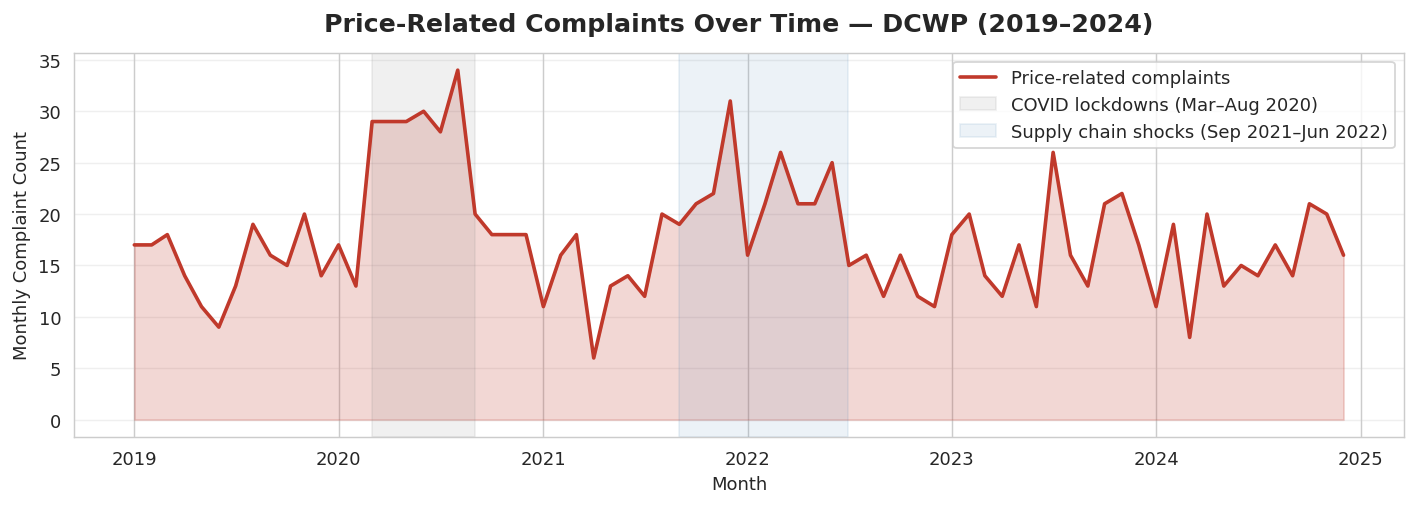

In [1]:
# Time series with crisis period annotations

### 6.2 Top 10 Complaint Codes by Volume

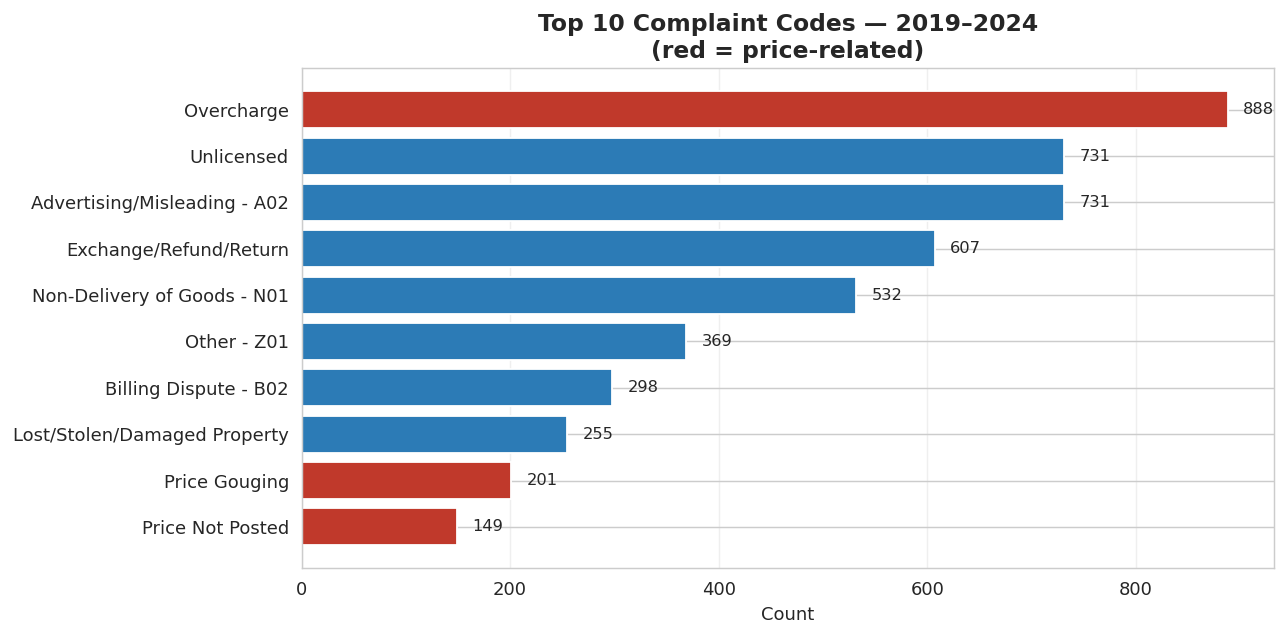

In [1]:
# Horizontal bar chart — price-related codes highlighted in red

### 6.3 Complaint Volume by Borough

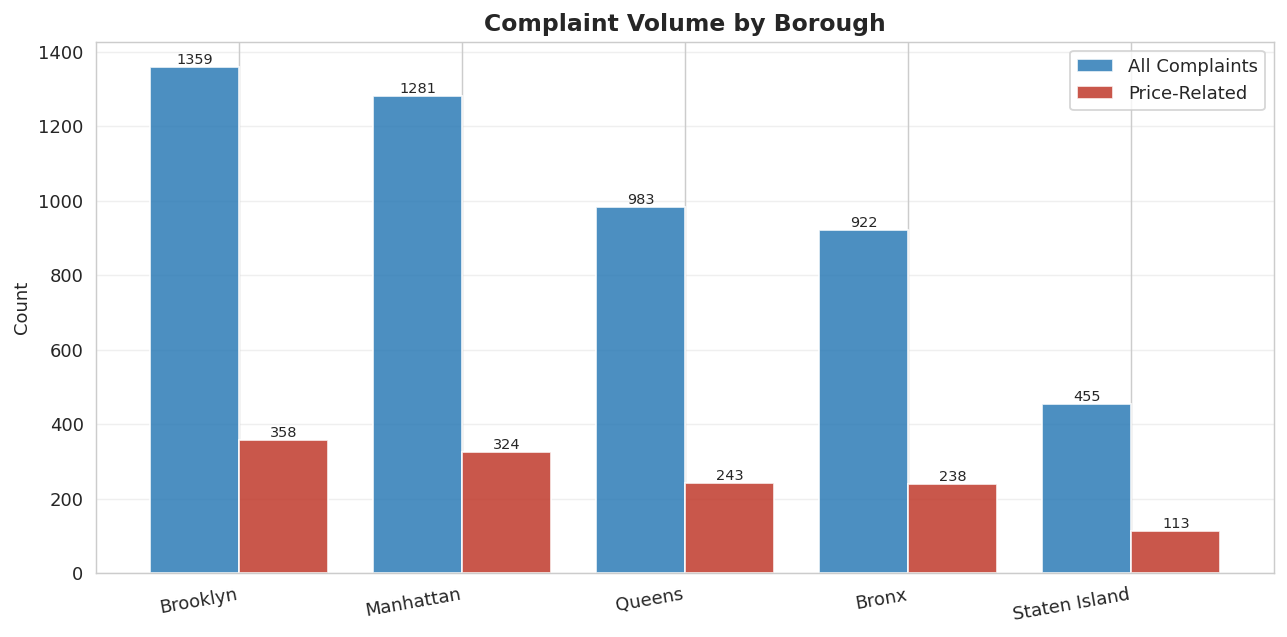

In [1]:
# Side-by-side: all complaints vs. price-related

### 6.4 Outcomes for Price-Related Complaints

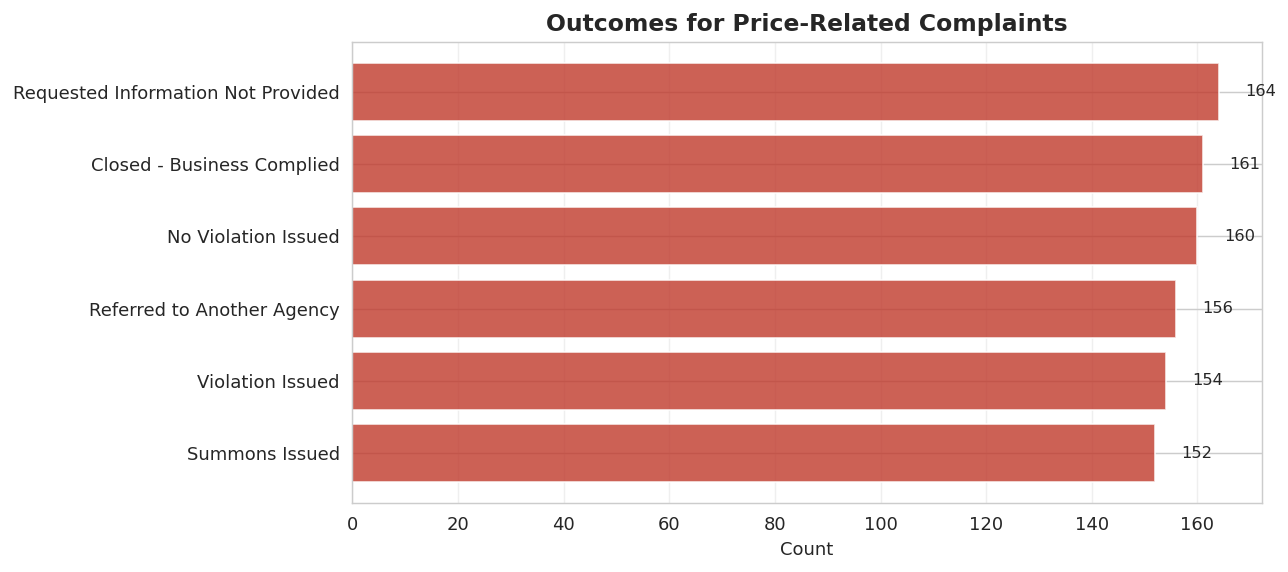

In [1]:
# Bar chart of resolution results

## 7. Key Findings

1. **Price-related complaints spike during economic crises.** The combined "Price Gouging + Overcharge + Price Not Posted + Surcharge" category surged during COVID-19 lockdowns (March–August 2020) and again during 2021–2022 supply chain disruptions — directly mirroring the enforcement environment faced by the OAG.

2. **Overcharge is the most common price violation**, far exceeding discrete "Price Gouging" filings — suggesting that broader overcharge enforcement may have more investigative surface area than the headline complaint code alone.

3. **The Bronx shows a disproportionately high share of price-related complaints** relative to total complaint volume, consistent with its demographics and density of essential retail — an equity consideration relevant to OAG consumer protection priorities.

4. **311 is the dominant intake channel**, accounting for most complaints. Online intake skews toward price-related complaints at a higher rate, suggesting more digitally-engaged filers may be reporting pricing issues more often.

5. **Most price-related complaints close within 30 days** (~65%), but a meaningful tail extends past 90 days — likely reflecting complex business-dispute cases requiring documentation from both parties.

## 8. Limitations & Next Steps

- Complaint data reflects *reported* violations only; underreporting in non-English-speaking communities is a known gap in 311-based datasets.
- Joining with Census ACS data (income, language, density) could test whether complaint outcomes differ systematically across community types — a natural equity extension.
- Business-level repeat violators could be surfaced using `business_unique_id`, enabling targeted enforcement prioritization.
- A PostgreSQL backend with indexed `intake_date` and `borough` columns would support production-scale querying across the full historical dataset.

---
*Dataset: [DCWP Consumer Complaints — NYC Open Data](https://data.cityofnewyork.us/Business/DCWP-Consumer-Complaints/nre2-6m2s/about_data)*  
*Code: [github.com/DanielIbrag](https://github.com/DanielIbrag)*